In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("mi_selected_features.csv")

In [3]:
dataset.isnull().sum()

AGE              0
SEX              0
INF_ANAM         0
STENOK_AN        0
FK_STENOK        0
IBS_POST         0
GB               0
DLIT_AG          0
S_AD_ORIT        0
D_AD_ORIT        0
ant_im           0
lat_im           0
ritm_ecg_p_01    0
L_BLOOD          0
ROE              0
TIME_B_S         0
NA_R_1_n         0
NOT_NA_1_n       0
ANT_CA_S_n       0
ASP_S_n          0
LET_IS           0
dtype: int64

In [4]:
def quanqual(dataset):
    quan=[]
    qual=[]
    for columnName in dataset.columns:
        if dataset[columnName].dtype=='O':
            qual.append(columnName)
        else:
            quan.append(columnName)
    return quan,qual
quan,qual=quanqual(dataset)

In [5]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Max","Min","25%","50%","75%","100%","IQR","1.5IQR","LesserRange","GreaterRange","Skew","Kurtosis"],columns=quan)
for columnName in quan:
    descriptive.loc["Mean",columnName]=dataset[columnName].mean()
    descriptive.loc["Median",columnName]=dataset[columnName].median()
    descriptive.loc["Mode",columnName]=dataset[columnName].mode()[0]
    descriptive.loc["Max",columnName]=dataset[columnName].max()
    descriptive.loc["Min",columnName]=dataset[columnName].min()

    descriptive.loc["25%",columnName]=dataset.describe()[columnName]["25%"]
    descriptive.loc["50%",columnName]=dataset.describe()[columnName]["50%"]
    descriptive.loc["75%",columnName]=dataset.describe()[columnName]["75%"]
    descriptive.loc["100%",columnName]=dataset.describe()[columnName]["max"]

    descriptive.loc["IQR",columnName]=descriptive.loc["75%",columnName]-descriptive.loc["25%",columnName]
    descriptive.loc["1.5IQR",columnName]=1.5*descriptive.loc["IQR",columnName]
    descriptive.loc["LesserRange",columnName]=descriptive.loc["25%",columnName]-descriptive.loc["1.5IQR",columnName]
    descriptive.loc["GreaterRange",columnName]=descriptive.loc["75%",columnName]+descriptive.loc["1.5IQR",columnName]
    descriptive.loc["Skew",columnName]=dataset[columnName].skew()
    descriptive.loc["Kurtosis",columnName]=dataset[columnName].kurt()

In [6]:
for columnName in quan:
    if columnName!='LET_IS':
        lower=descriptive.loc["LesserRange",columnName]
        upper=descriptive.loc["GreaterRange",columnName]
        dataset[columnName]=dataset[columnName].clip(lower=lower,upper=upper)

In [7]:
dataset['LET_IS'].value_counts()

LET_IS
0    1429
1     110
3      54
7      27
6      27
4      23
2      18
5      12
Name: count, dtype: int64

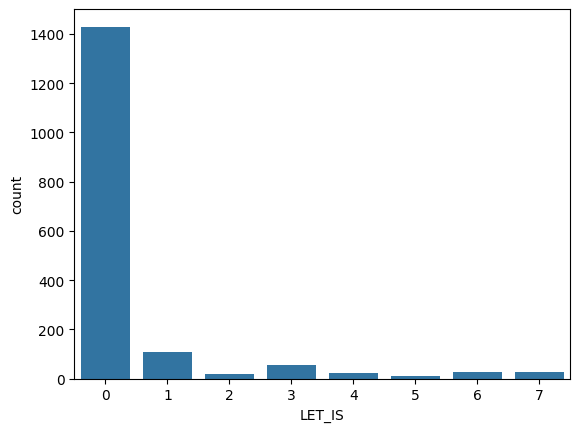

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='LET_IS', data=dataset)
plt.show()

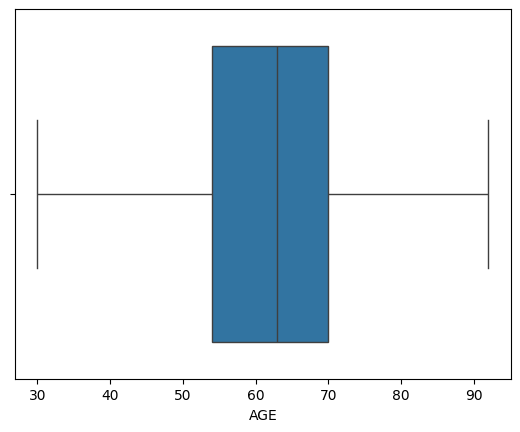

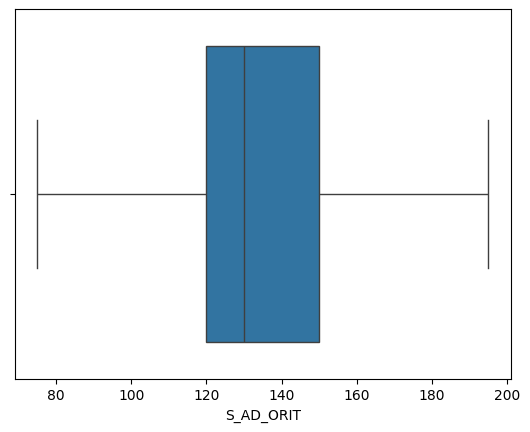

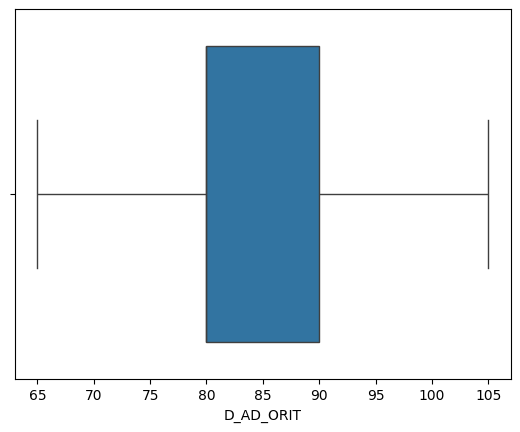

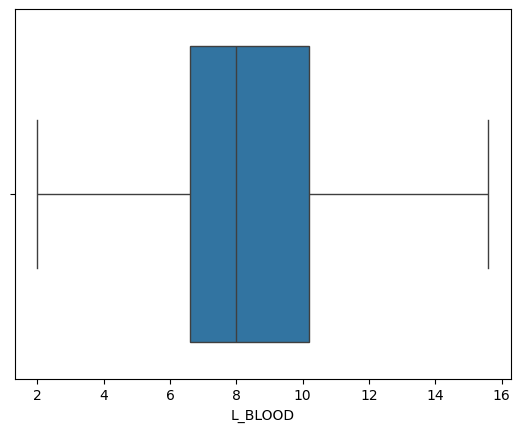

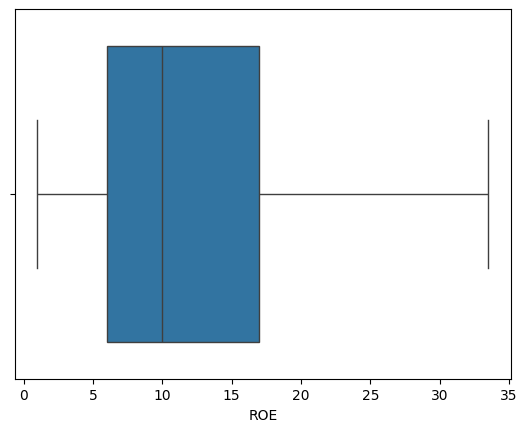

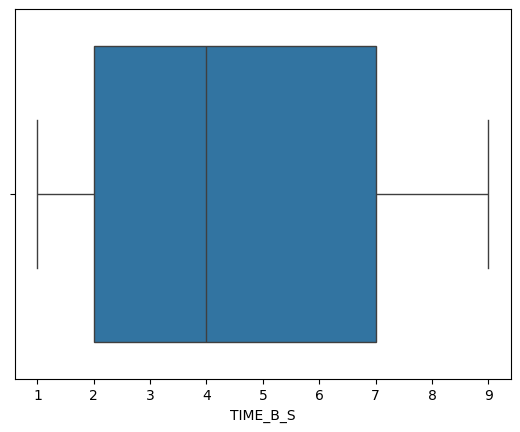

In [9]:
num_cols = ['AGE','S_AD_ORIT','D_AD_ORIT','L_BLOOD','ROE','TIME_B_S']
for col in num_cols:
    sns.boxplot(x=dataset[col])
    plt.show()

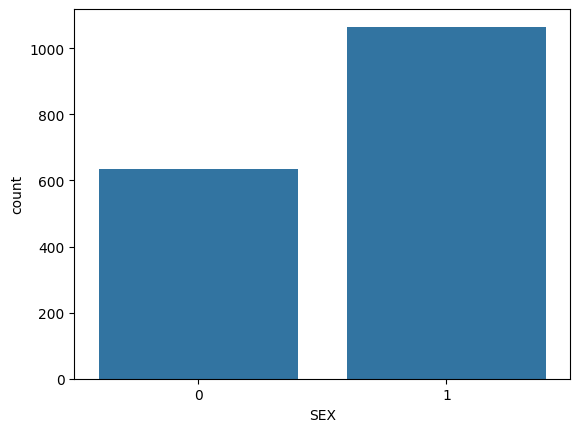

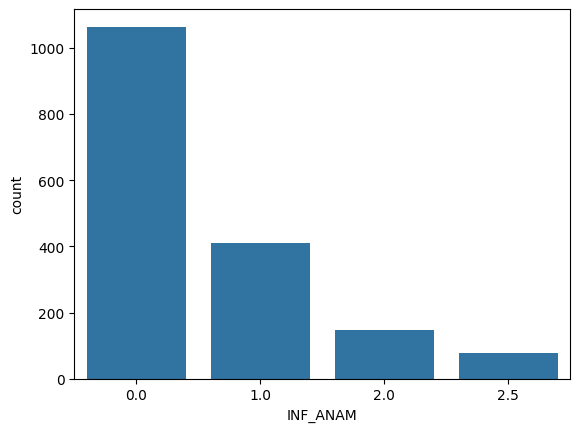

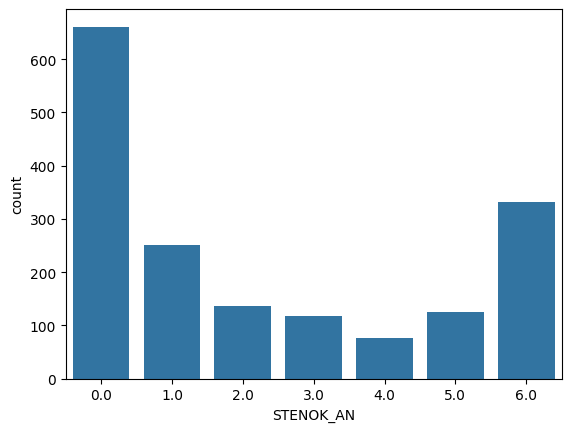

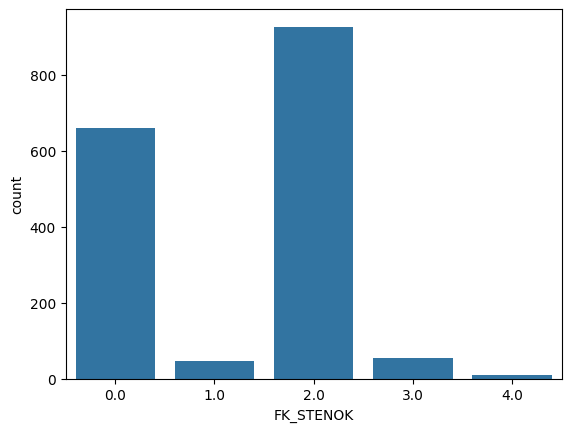

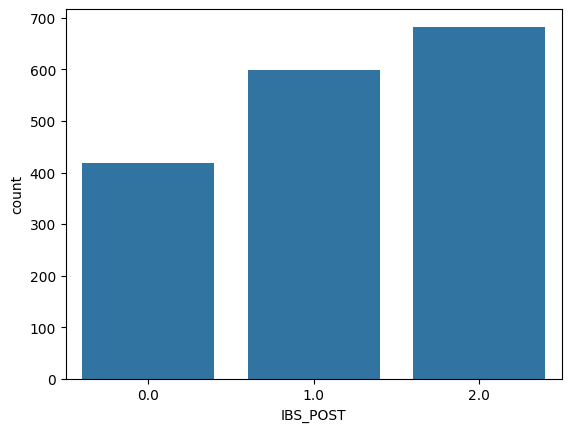

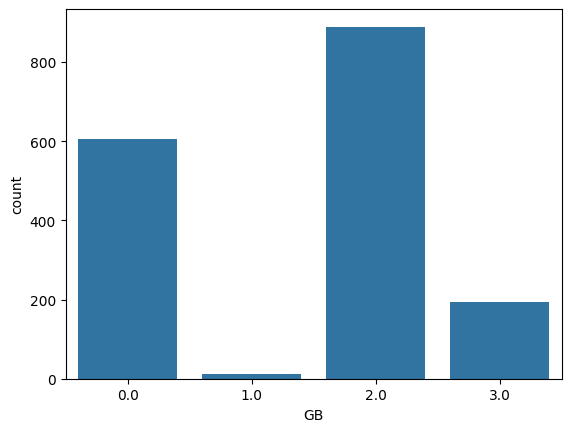

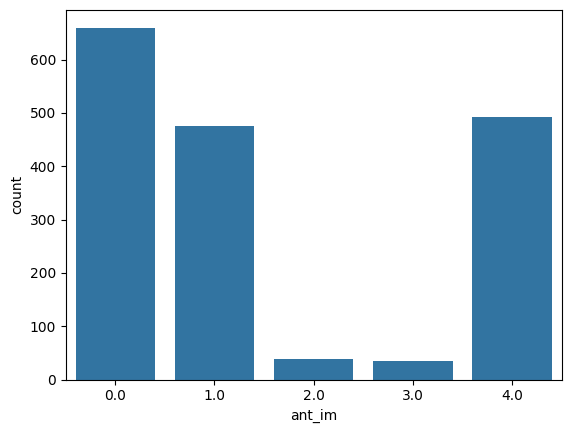

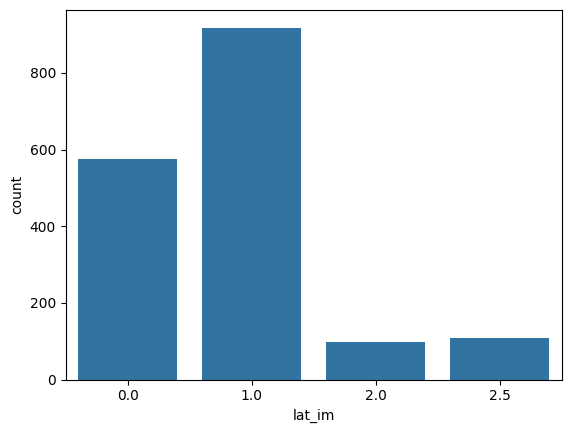

In [10]:
cat_col=['SEX','INF_ANAM','STENOK_AN','FK_STENOK','IBS_POST','GB','ant_im','lat_im']
for col in cat_col:
    sns.countplot(x=col, data=dataset)
    plt.show()

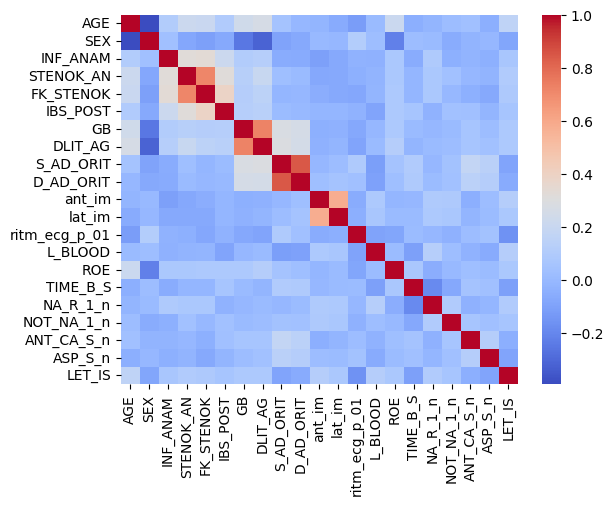

In [11]:
sns.heatmap(dataset.corr(), cmap='coolwarm')
plt.show()

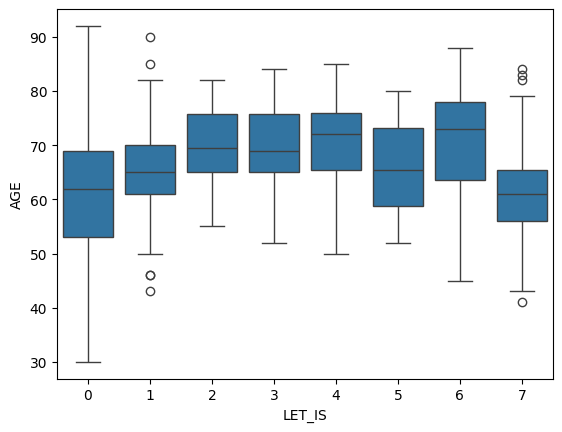

In [12]:
sns.boxplot(x='LET_IS', y='AGE', data=dataset)
plt.show()

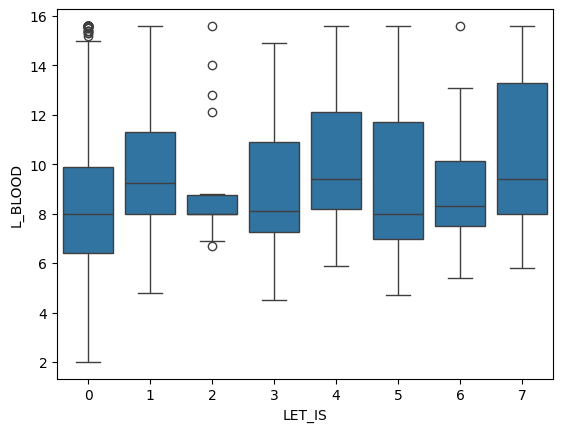

In [13]:
sns.boxplot(x='LET_IS', y='L_BLOOD', data=dataset)
plt.show()


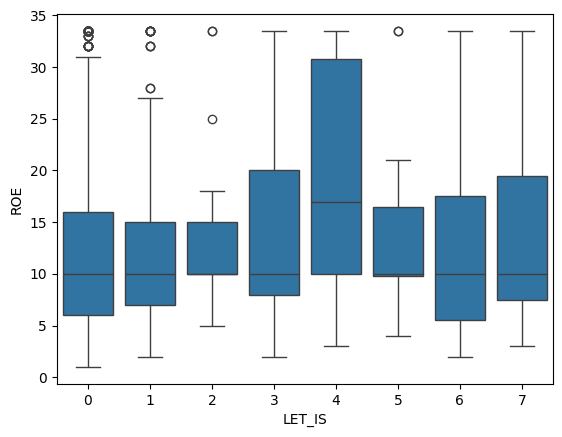

In [14]:
sns.boxplot(x='LET_IS', y='ROE', data=dataset)
plt.show()

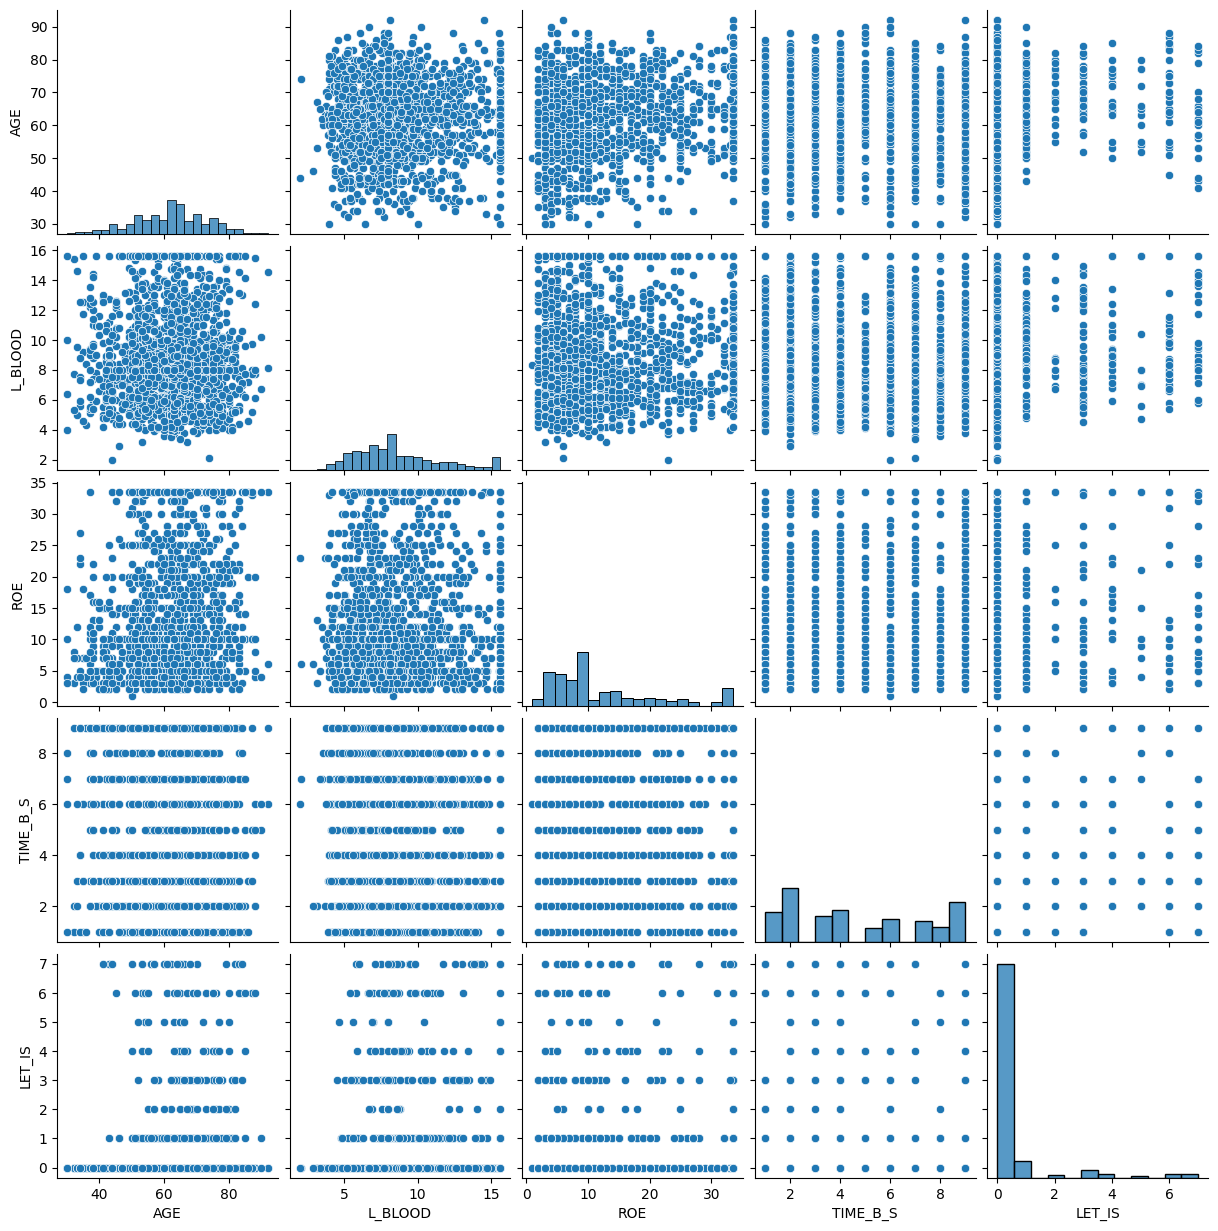

In [18]:
sns.pairplot(dataset[['AGE','L_BLOOD','ROE','TIME_B_S','LET_IS']])
plt.show()